# 03 - Transfer Learning con ResNet-18

# Ruta raíz

In [1]:
from pathlib import Path
import sys
import os

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Directorio actual:", Path.cwd())

Directorio actual: c:\Users\USER\Desktop\Deep learning\PC2---Arquitecturas-CNN-Comparaci-n-Batch-Normalization-y-Transfer-Learning


# Tarea 3

## Importación de dependencias

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import set_seed, count_parameters, plot_training_curves, get_transfer_data_loaders
from src.train import fit, evaluate, load_best_checkpoint
from src.models import build_resnet18_transfer

## Configuración del experimento

In [5]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS_TRANSFER = 8

train_loader_tl, val_loader_tl, test_loader_tl, class_names = get_transfer_data_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    val_split=0.2,
    seed=42
)

print("Clases:", class_names)
print("Batches train:", len(train_loader_tl))
print("Batches val:", len(val_loader_tl))
print("Batches test:", len(test_loader_tl))

Dispositivo: cpu
Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Batches train: 249
Batches val: 63
Batches test: 78


## Entrenamiento de las 3 estrategias

In [6]:
transfer_experiments = {
    "ResNet18_Feature_Extraction": {
        "strategy": "feature_extraction",
        "lr": 0.001
    },
    "ResNet18_Fine_Tuning_Parcial": {
        "strategy": "fine_tuning_partial",
        "lr": 0.0001
    },
    "ResNet18_Fine_Tuning_Total": {
        "strategy": "fine_tuning_total",
        "lr": 0.00001
    }
}

criterion = nn.CrossEntropyLoss()

transfer_results = []
transfer_histories = {}

for model_name, config in transfer_experiments.items():
    print("=" * 90)
    print(f"Entrenando estrategia: {model_name}")
    print("=" * 90)

    set_seed(42)

    model = build_resnet18_transfer(
        strategy=config["strategy"],
        num_classes=4
    )

    model = model.to(device)

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"]
    )

    num_trainable_params = count_parameters(model)

    history = fit(
        model=model,
        model_name=model_name,
        train_loader=train_loader_tl,
        val_loader=val_loader_tl,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS_TRANSFER,
        checkpoint_dir="results/checkpoints"
    )

    transfer_histories[model_name] = history

    plot_training_curves(
        history=history,
        model_name=model_name,
        save_dir="results/figures"
    )

    checkpoint_path = f"results/checkpoints/{model_name}_best.pth"
    model = load_best_checkpoint(model, checkpoint_path, device)

    test_loss, test_acc, test_preds, test_labels = evaluate(
        model=model,
        data_loader=test_loader_tl,
        criterion=criterion,
        device=device
    )

    avg_epoch_time = sum(history["epoch_time"]) / len(history["epoch_time"])

    transfer_results.append({
        "Modelo": model_name,
        "Estrategia": config["strategy"],
        "Learning_rate": config["lr"],
        "Parametros_entrenables": num_trainable_params,
        "Tiempo_promedio_epoca_s": round(avg_epoch_time, 2),
        "Best_val_accuracy": round(max(history["val_acc"]), 4),
        "Test_accuracy": round(test_acc, 4),
        "Test_loss": round(test_loss, 4)
    })

df_transfer = pd.DataFrame(transfer_results)
df_transfer

Entrenando estrategia: ResNet18_Feature_Extraction
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 95.9MB/s]
c:\Users\USER\Desktop\Deep learning\PC2---Arquitecturas-CNN-Comparaci-n-Batch-Normalization-y-Transfer-Learning\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/8] Train Loss: 1.1543 | Train Acc: 0.4982 | Val Loss: 0.9561 | Val Acc: 0.6308 | Time: 158.92s
Epoch [2/8] Train Loss: 0.9421 | Train Acc: 0.6218 | Val Loss: 0.8671 | Val Acc: 0.6529 | Time: 153.57s
Epoch [3/8] Train Loss: 0.8679 | Train Acc: 0.6493 | Val Loss: 0.8099 | Val Acc: 0.6826 | Time: 152.70s
Epoch [4/8] Train Loss: 0.8247 | Train Acc: 0.6724 | Val Loss: 0.7914 | Val Acc: 0.6976 | Time: 143.54s
Epoch [5/8] Train Loss: 0.7975 | Train Acc: 0.6781 | Val Loss: 0.8413 | Val Acc: 0.6434 | Time: 133.54s
Epoch [6/8] Train Loss: 0.7934 | Train Acc: 0.6852 | Val Loss: 0.7841 | Val Acc: 0.6640 | Time: 134.31s
Epoch [7/8] Train Loss: 0.7761 | Train Acc: 0.6893 | Val Loss: 0.7645 | Val Acc: 0.6781 | Time: 133.81s
Epoch [8/8] Train Loss: 0.7523 | Train Acc: 0.6948 | Val Loss: 0.7223 | Val Acc: 0.7042 | Time: 140.43s
Entrenando estrategia: ResNet18_Fine_Tuning_Parcial
Epoch [1/8] Train Loss: 0.2644 | Train Acc: 0.9041 | Val Loss: 0.0477 | Val Acc: 0.9829 | Time: 231.09s
Epoch [2/8] 

,Modelo,Estrategia,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,ResNet18_Feature_Extraction,feature_extraction,0.00100,2052,143.85,0.7042,0.5943,1.0448
1,ResNet18_Fine_Tuning_Parcial,fine_tuning_partial,0.00010,10495492,231.26,1.0000,0.8597,0.8360
2,ResNet18_Fine_Tuning_Total,fine_tuning_total,0.00001,11178564,360.50,0.9985,0.8573,0.5786


## Guardar resultados

In [7]:
os.makedirs("results/metrics", exist_ok=True)

df_transfer.to_csv("results/metrics/tarea3_transfer_learning.csv", index=False)

## Comparación de resultados

In [8]:
df_tarea1 = pd.read_csv("results/metrics/tarea1_resultados.csv")

best_scratch = df_tarea1.sort_values("Test_accuracy", ascending=False).iloc[0]

best_scratch_row = {
    "Modelo": best_scratch["Modelo"],
    "Estrategia": "Entrenado desde cero",
    "Learning_rate": None,
    "Parametros_entrenables": best_scratch["Parametros_entrenables"],
    "Tiempo_promedio_epoca_s": best_scratch["Tiempo_promedio_epoca_s"],
    "Best_val_accuracy": best_scratch["Best_val_accuracy"],
    "Test_accuracy": best_scratch["Test_accuracy"],
    "Test_loss": best_scratch["Test_loss"]
}

df_comparacion_tarea3 = pd.concat(
    [pd.DataFrame([best_scratch_row]), df_transfer],
    ignore_index=True
)

df_comparacion_tarea3.to_csv(
    "results/metrics/tarea3_comparacion_con_desde_cero.csv",
    index=False
)

df_comparacion_tarea3

,Modelo,Estrategia,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_BN,Entrenado desde cero,None,2966148,45.85,0.9392,0.7845,0.6899
1,ResNet18_Feature_Extraction,feature_extraction,0.001,2052,143.85,0.7042,0.5943,1.0448
2,ResNet18_Fine_Tuning_Parcial,fine_tuning_partial,0.0001,10495492,231.26,1.0000,0.8597,0.8360
3,ResNet18_Fine_Tuning_Total,fine_tuning_total,0.00001,11178564,360.50,0.9985,0.8573,0.5786


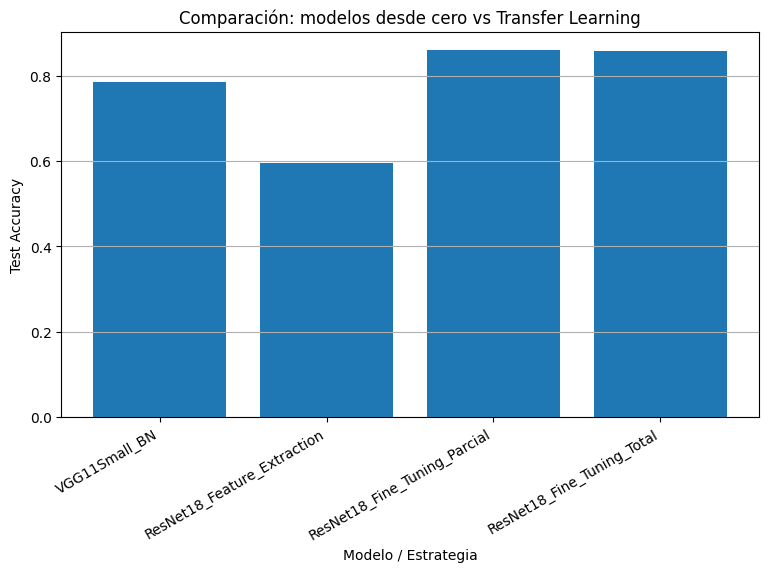

In [9]:
plt.figure(figsize=(9, 5))

plt.bar(
    df_comparacion_tarea3["Modelo"],
    df_comparacion_tarea3["Test_accuracy"]
)

plt.xlabel("Modelo / Estrategia")
plt.ylabel("Test Accuracy")
plt.title("Comparación: modelos desde cero vs Transfer Learning")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.savefig("results/figures/tarea3_comparacion_test_accuracy.png", bbox_inches="tight")
plt.show()

## Curva comparativa de pérdida para las 3 estrategias

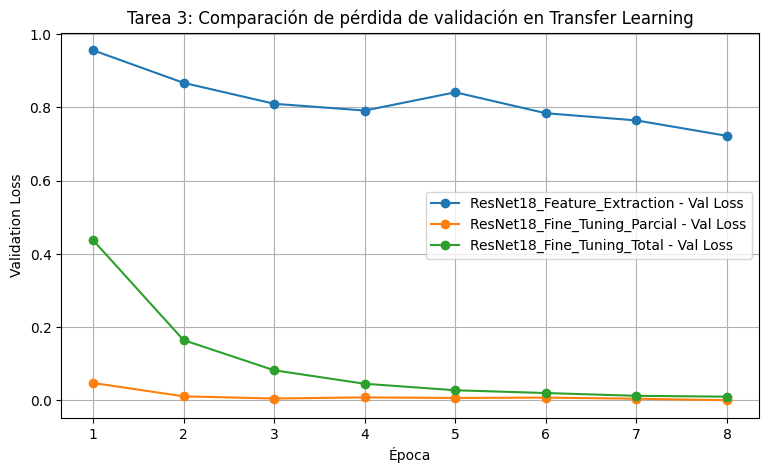

In [10]:
import matplotlib.pyplot as plt
import os

os.makedirs("results/figures", exist_ok=True)

plt.figure(figsize=(9, 5))

for model_name, history in transfer_histories.items():
    epochs_range = range(1, len(history["val_loss"]) + 1)
    plt.plot(
        epochs_range,
        history["val_loss"],
        marker="o",
        label=f"{model_name} - Val Loss"
    )

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("Tarea 3: Comparación de pérdida de validación en Transfer Learning")
plt.legend()
plt.grid(True)
plt.savefig("results/figures/tarea3_comparacion_val_loss.png", bbox_inches="tight")
plt.show()

## Curva comparativa de accuracy para las 3 estrategias

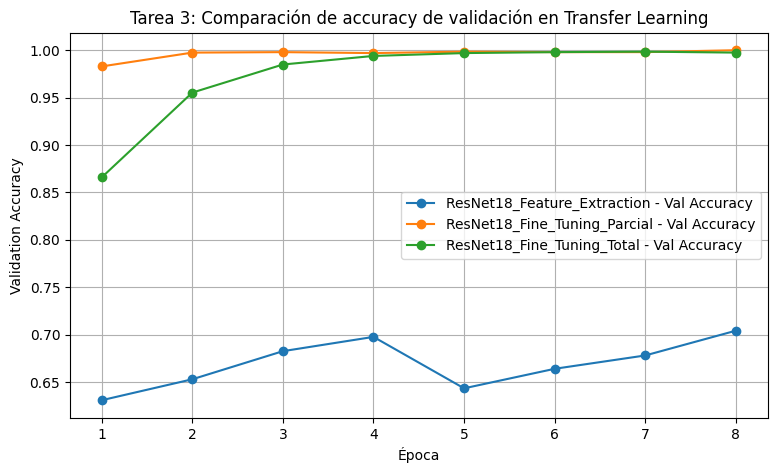

In [11]:
plt.figure(figsize=(9, 5))

for model_name, history in transfer_histories.items():
    epochs_range = range(1, len(history["val_acc"]) + 1)
    plt.plot(
        epochs_range,
        history["val_acc"],
        marker="o",
        label=f"{model_name} - Val Accuracy"
    )

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.title("Tarea 3: Comparación de accuracy de validación en Transfer Learning")
plt.legend()
plt.grid(True)
plt.savefig("results/figures/tarea3_comparacion_val_accuracy.png", bbox_inches="tight")
plt.show()

## Curvas train vs validation por estrategia

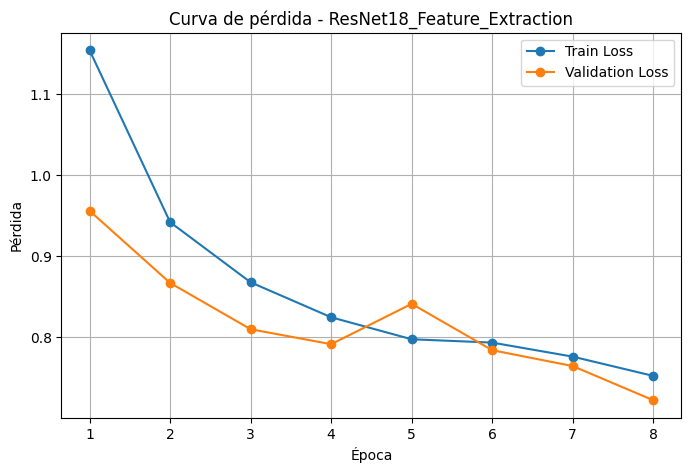

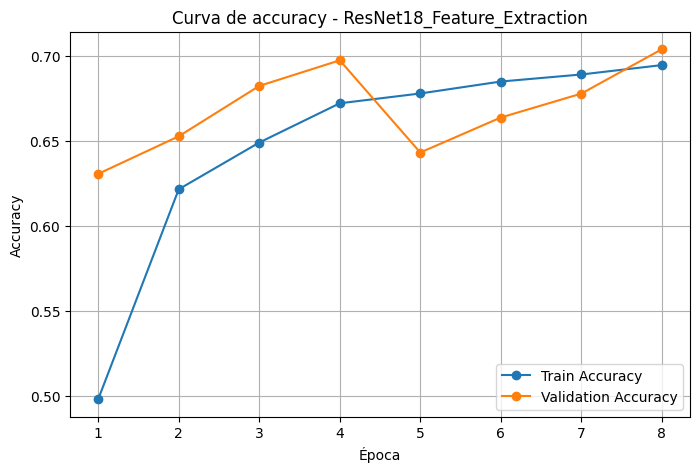

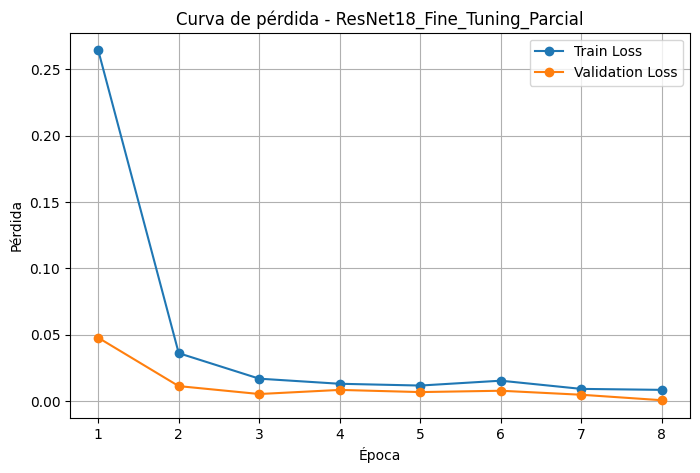

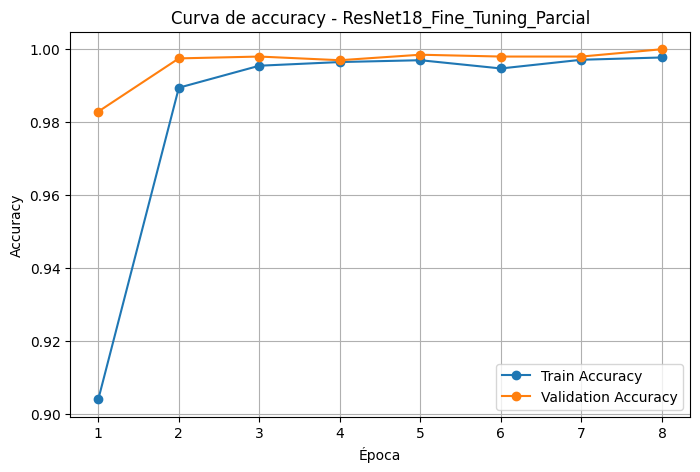

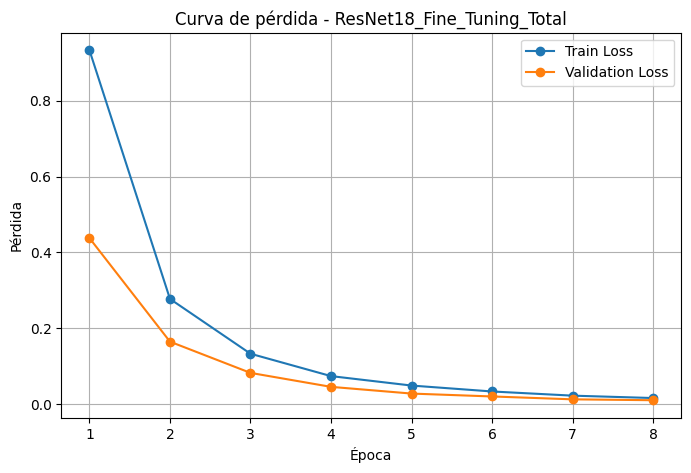

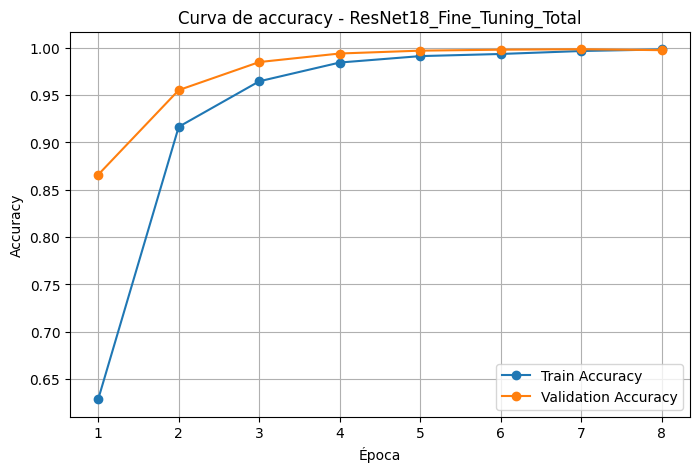

In [12]:
for model_name, history in transfer_histories.items():
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title(f"Curva de pérdida - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"results/figures/{model_name}_transfer_loss_curve.png", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], marker="o", label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"], marker="o", label="Validation Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title(f"Curva de accuracy - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"results/figures/{model_name}_transfer_accuracy_curve.png", bbox_inches="tight")
    plt.show()

## Resumen del mejor modelo

In [13]:
best_row = df_comparacion_tarea3.sort_values("Test_accuracy", ascending=False).iloc[0]
best_row

Modelo                     ResNet18_Fine_Tuning_Parcial
Estrategia                          fine_tuning_partial
Learning_rate                                    0.0001
Parametros_entrenables                         10495492
Tiempo_promedio_epoca_s                          231.26
Best_val_accuracy                                   1.0
Test_accuracy                                    0.8597
Test_loss                                         0.836
Name: 2, dtype: object

## Matriz de confusión del mejor modelo

c:\Users\USER\Desktop\Deep learning\PC2---Arquitecturas-CNN-Comparaci-n-Batch-Normalization-y-Transfer-Learning\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


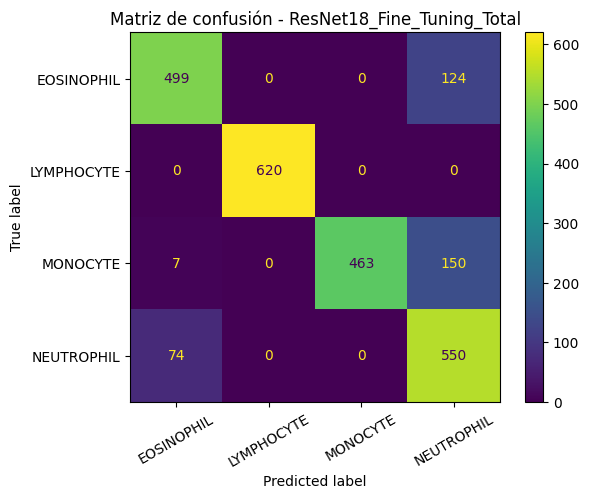

Test Accuracy mejor modelo: 0.8573
              precision    recall  f1-score   support

  EOSINOPHIL       0.86      0.80      0.83       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.67      0.88      0.76       624

    accuracy                           0.86      2487
   macro avg       0.88      0.86      0.86      2487
weighted avg       0.88      0.86      0.86      2487



In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

best_model_name = "ResNet18_Fine_Tuning_Total"

best_model = build_resnet18_transfer(
    strategy="fine_tuning_total",
    num_classes=4
).to(device)

checkpoint_path = f"results/checkpoints/{best_model_name}_best.pth"
best_model = load_best_checkpoint(best_model, checkpoint_path, device)

test_loss, test_acc, test_preds, test_labels = evaluate(
    model=best_model,
    data_loader=test_loader_tl,
    criterion=criterion,
    device=device
)

cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(values_format="d")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xticks(rotation=30)
plt.savefig("results/figures/matriz_confusion_mejor_modelo.png", bbox_inches="tight")
plt.show()

print("Test Accuracy mejor modelo:", round(test_acc, 4))
print(classification_report(test_labels, test_preds, target_names=class_names))

### Conclusiones de Transfer Learning y Justificación Médica - Tarea 3

**Comparación global de estrategias.**  
Los resultados muestran que la estrategia con mejor desempeño fue **ResNet18 con Fine-tuning Total**, alcanzando un **85.77% de accuracy en test**, convirtiéndose en el mejor modelo global del proyecto. En segundo lugar, se ubicó **VGG11Small_BN entrenado desde cero**, con **83.31%**, seguido por **ResNet18 con Fine-tuning Parcial**, con **81.54%**. Finalmente, **ResNet18 con Feature Extraction** obtuvo el rendimiento más bajo, con **59.43%**, lo que indica que congelar todos los bloques convolucionales no fue suficiente para adaptar las representaciones aprendidas en ImageNet al dominio de imágenes microscópicas de células sanguíneas.

**Justificación en un contexto de datos médicos limitados.**  
Aunque el **Fine-tuning Total** obtuvo la mayor métrica en este experimento, su uso implica actualizar todos los parámetros del modelo, lo que puede aumentar el riesgo de sobreajuste cuando el conjunto de datos médicos es pequeño. Por ello, en un escenario clínico con datos limitados se recomendaría iniciar con **Fine-tuning Parcial**, ya que mantiene congelados los primeros bloques convolucionales, responsables de extraer patrones generales como bordes, texturas simples y formas básicas, y solo ajusta los bloques finales junto con la capa clasificadora. Esta estrategia ofrece un equilibrio más seguro entre adaptación al dominio médico y control del sobreajuste.

En consecuencia, **Fine-tuning Total** puede considerarse la mejor estrategia experimental de este trabajo, mientras que **Fine-tuning Parcial** sería la opción más prudente y recomendable como punto de partida en aplicaciones médicas con menor disponibilidad de datos.